# SSM(State Space Model)基礎 実践教材

このノートブックは、Mambaを理解するために必要なSSMの考え方を最短経路で学ぶ補助教材です。

扱う内容:

- 状態 `h_t` を持つ系列モデルとしてのSSM
- 連続時間SSMから離散時間SSMへの変換
- 再帰計算と畳み込み計算が同じ出力を作ること
- 長期記憶と忘却の直感
- Mambaで重要になる「入力に応じてパラメータを変える」発想

主な参考資料:

- Gu, Dao, *Mamba: Linear-Time Sequence Modeling with Selective State Spaces*, 2023: https://arxiv.org/abs/2312.00752
- Gu et al., *Efficiently Modeling Long Sequences with Structured State Spaces*, 2021: https://arxiv.org/abs/2111.00396
- The Annotated S4: https://srush.github.io/annotated-s4/

## 0. 依存関係

この補助教材は `numpy` だけで実行できます。可視化セルでは `matplotlib` がある場合だけ図を表示します。

In [1]:
import math
from pathlib import Path
import numpy as np

try:
    import matplotlib.pyplot as plt
    from matplotlib import font_manager

    # 日本語フォントのファイルをMatplotlibへ直接登録する。
    # family名だけの指定より確実で、図中の日本語が□になるのを防げる。
    japanese_font_path = '/usr/share/fonts/truetype/droid/DroidSansFallbackFull.ttf'
    if Path(japanese_font_path).exists():
        font_manager.fontManager.addfont(japanese_font_path)
        japanese_font_name = font_manager.FontProperties(
            fname=japanese_font_path
        ).get_name()
        plt.rcParams['font.family'] = ['DejaVu Sans', japanese_font_name]
    plt.rcParams['axes.unicode_minus'] = False
    HAS_MPL = True
except Exception:
    HAS_MPL = False

np.set_printoptions(precision=3, suppress=True)
print('numpy:', np.__version__)
print('matplotlib:', 'available' if HAS_MPL else 'not available')

numpy: 2.4.6
matplotlib: available


## 1. SSMを系列モデルとして見る

離散時間の最も基本的なSSMは次の形です。

$$h_t = A h_{t-1} + B x_t$$

$$y_t = C h_t + D x_t$$

`x_t` は時刻 `t` の入力、`h_t` は過去情報を圧縮した状態、`y_t` は出力です。RNNに似ていますが、基本形は線形です。MambaではこのSSMのパラメータの一部を入力から作ることで、内容に応じて覚える・忘れる動作を実現します。

In [2]:
def run_ssm_recurrence(x, A, B, C, D=0.0, h0=None):
    x = np.asarray(x, dtype=float)
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float).reshape(-1)
    C = np.asarray(C, dtype=float).reshape(-1)
    n = A.shape[0]
    h = np.zeros(n) if h0 is None else np.asarray(h0, dtype=float).copy()
    hs, ys = [], []
    for xt in x:
        h = A @ h + B * xt
        y = C @ h + D * xt
        hs.append(h.copy())
        ys.append(float(y))
    return np.stack(hs), np.array(ys)

x = np.array([1, 0, 0, 0, 0, 0], dtype=float)
A = np.array([[0.8]])
B = np.array([1.0])
C = np.array([1.0])
hs, y = run_ssm_recurrence(x, A, B, C)
print('input :', x)
print('state :', hs[:, 0])
print('output:', y)

input : [1. 0. 0. 0. 0. 0.]
state : [1.    0.8   0.64  0.512 0.41  0.328]
output: [1.    0.8   0.64  0.512 0.41  0.328]


上の例では、最初の入力 `1` が状態に入り、その後 `A=0.8` によって少しずつ減衰します。`A` の固有値が1に近いほど長く覚え、0に近いほどすぐ忘れます。

A= 0.2: [1.    0.2   0.04  0.008 0.002 0.    0.    0.    0.    0.   ]
A= 0.6: [1.    0.6   0.36  0.216 0.13  0.078 0.047 0.028 0.017 0.01 ]
A= 0.9: [1.    0.9   0.81  0.729 0.656 0.59  0.531 0.478 0.43  0.387]
A=0.98: [1.    0.98  0.96  0.941 0.922 0.904 0.886 0.868 0.851 0.834]


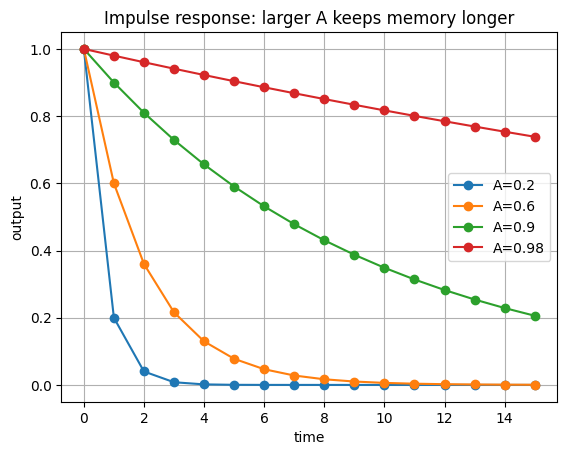

In [3]:
def impulse_response(a_values, length=20):
    x = np.r_[1.0, np.zeros(length - 1)]
    rows = {}
    for a in a_values:
        _, y = run_ssm_recurrence(x, np.array([[a]]), np.array([1.0]), np.array([1.0]))
        rows[a] = y
    return rows

responses = impulse_response([0.2, 0.6, 0.9, 0.98], length=16)
for a, r in responses.items():
    print(f'A={a:>4}:', np.round(r[:10], 3))

if HAS_MPL:
    for a, r in responses.items():
        plt.plot(r, marker='o', label=f'A={a}')
    plt.title('Impulse response: larger A keeps memory longer')
    plt.xlabel('time')
    plt.ylabel('output')
    plt.legend()
    plt.grid(True)
    plt.show()

## 2. 連続時間から離散時間へ

S4やMambaの背景では、連続時間の状態方程式を考えます。

$$\frac{dh(t)}{dt} = A h(t) + B x(t), \quad y(t) = C h(t)$$

コンピュータ上では時刻を刻むので、ステップ幅 `Delta` で離散化します。1次元で入力を区間内一定とみなすと、

$$\bar{A}=\exp(\Delta A), \quad \bar{B}=\frac{\exp(\Delta A)-1}{A}B$$

となります。Mambaではこの `Delta` も入力から作り、トークンごとに時間スケールを変えます。

In [4]:
def discretize_1d(A_cont, B_cont, delta):
    A_bar = math.exp(delta * A_cont)
    if abs(A_cont) < 1e-8:
        B_bar = delta * B_cont
    else:
        B_bar = (math.exp(delta * A_cont) - 1.0) / A_cont * B_cont
    return A_bar, B_bar

A_cont = -1.0
B_cont = 1.0
for delta in [0.05, 0.2, 1.0, 2.0]:
    A_bar, B_bar = discretize_1d(A_cont, B_cont, delta)
    print(f'Delta={delta:>4}: A_bar={A_bar:.3f}, B_bar={B_bar:.3f}')

Delta=0.05: A_bar=0.951, B_bar=0.049
Delta= 0.2: A_bar=0.819, B_bar=0.181
Delta= 1.0: A_bar=0.368, B_bar=0.632
Delta= 2.0: A_bar=0.135, B_bar=0.865


`Delta` が大きいほど、連続時間上で長い時間が一歩で進むため、状態はより強く減衰します。Mambaの選択的SSMでは、この性質を使って「この入力では状態を大きく更新する」「この入力では過去を保持する」といった制御をします。

## 3. 再帰と畳み込みは同じ計算を表せる

`A, B, C` が時刻に依存しない場合、SSMは畳み込みとしても書けます。

$$y_t = \sum_{k=0}^{t} K_k x_{t-k}$$

$$K_k = C A^k B$$

これがS4系モデルの重要なポイントです。学習時には畳み込みとして並列計算でき、推論時には再帰として状態だけを更新できます。

In [5]:
def ssm_kernel(A, B, C, length):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float).reshape(-1)
    C = np.asarray(C, dtype=float).reshape(-1)
    Ak = np.eye(A.shape[0])
    kernel = []
    for _ in range(length):
        kernel.append(float(C @ (Ak @ B)))
        Ak = A @ Ak
    return np.array(kernel)

def causal_convolution(x, kernel):
    y = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        for k in range(t + 1):
            y[t] += kernel[k] * x[t - k]
    return y

rng = np.random.default_rng(0)
x = rng.normal(size=12)
A = np.diag([0.4, 0.8])
B = np.array([1.0, -0.5])
C = np.array([0.7, 1.2])

_, y_rec = run_ssm_recurrence(x, A, B, C)
K = ssm_kernel(A, B, C, len(x))
y_conv = causal_convolution(x, K)

print('kernel:', np.round(K[:8], 3))
print('recurrence output  :', np.round(y_rec[:8], 3))
print('convolution output :', np.round(y_conv[:8], 3))
print('max error:', np.max(np.abs(y_rec - y_conv)))

kernel: [ 0.1   -0.2   -0.272 -0.262 -0.228 -0.189 -0.154 -0.125]
recurrence output  : [ 0.013 -0.038  0.056 -0.115 -0.243 -0.047  0.036 -0.264]
convolution output : [ 0.013 -0.038  0.056 -0.115 -0.243 -0.047  0.036 -0.264]
max error: 2.220446049250313e-16


## 4. なぜMambaでは単純な畳み込みだけでは足りないのか

時刻不変のSSMでは、同じ `A, B, C` をすべての入力に使います。これは効率的ですが、離散トークン列では「このトークンは覚える」「このトークンは無視する」のような内容依存の判断が弱くなります。

Mambaの中心アイデアは、入力 `x_t` から `Delta_t, B_t, C_t` を作ることです。

$$h_t = \bar{A}_t h_{t-1} + \bar{B}_t x_t$$

$$y_t = C_t h_t$$

これにより、SSMは固定フィルタではなく、入力に応じて変化する選択的な再帰モデルになります。

In [6]:
def selective_1d_scan(x, gate, A_cont=-1.0):
    h = 0.0
    ys = []
    for xt, gt in zip(x, gate):
        delta = 0.05 + 2.0 * gt
        A_bar, B_bar = discretize_1d(A_cont, 1.0, delta)
        h = A_bar * h + B_bar * xt
        ys.append(h)
    return np.array(ys)

x = np.array([0, 0, 8, 0, 0, 1, 0, 0, 0, 0], dtype=float)
gate_ignore_big = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0], dtype=float)
gate_keep_big = np.zeros_like(x)

y_ignore = selective_1d_scan(x, gate_ignore_big)
y_keep = selective_1d_scan(x, gate_keep_big)
print('x       :', x)
print('gate    :', gate_ignore_big)
print('large Delta at x=8:', np.round(y_ignore, 3))
print('small Delta always:', np.round(y_keep, 3))

x       : [0. 0. 8. 0. 0. 1. 0. 0. 0. 0.]
gate    : [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
large Delta at x=8: [0.    0.    6.97  6.63  6.307 6.048 5.753 5.472 5.206 4.952]
small Delta always: [0.    0.    0.39  0.371 0.353 0.385 0.366 0.348 0.331 0.315]


この小さな例では `gate` が大きい時刻だけ `Delta` を大きくしています。`Delta` は単なるゲートそのものではありませんが、状態更新の時間スケールを変えられるため、Mambaの選択性の直感をつかむ入口になります。

## 5. 確認課題

1. `A=0.99` と `A=0.3` のインパルス応答を比べ、長期記憶の違いを説明してください。
2. `B` を大きくすると、入力の状態への入り方はどう変わりますか。
3. `C` の符号を変えると、状態と出力の関係はどう変わりますか。
4. `selective_1d_scan` で `gate` をいろいろ変え、どの時刻で状態が更新・忘却されるかを観察してください。
5. Mamba本体のノートブックに進み、`Delta_t, B_t, C_t` が入力から作られる場所を探してください。

### 解答例

1. `A=0.99` では、インパルスで一度入った情報が `0.99^t` のようにゆっくり減衰するため、かなり後の時刻まで影響が残ります。一方で `A=0.3` では `0.3^t` として急速に小さくなるため、数ステップ後にはほとんど忘却されます。したがって、`A` が 1 に近いほど長期記憶が強く、0 に近いほど短期的な情報だけを保持するモデルになります。

2. `B` は入力 `x_t` を状態 `h_t` にどれだけ強く注入するかを決める係数です。`B` を大きくすると、同じ入力でも状態の変化量が大きくなり、入力が記憶に強く書き込まれます。逆に `B` が小さいと、入力の影響は弱く、状態は過去から引き継いだ値により強く支配されます。

3. `C` は状態 `h_t` を出力 `y_t` に読み出す係数です。`C` の符号を反転すると、状態が正のとき出力は負になり、状態が負のとき出力は正になります。つまり、状態が持つ情報そのものは変わりませんが、出力として観測される向きが反転します。

4. `selective_1d_scan` では `gate` が大きい時刻ほど `Delta` が大きくなります。この教材の設定では、`Delta` が大きいと `A_bar = exp(A_cont * Delta)` が小さくなり、直前までの状態は強く忘却されます。同時に `B_bar` は大きくなり、その時刻の入力が状態へ強く入ります。したがって、`gate` を大きくした時刻は「過去を忘れ、新しい入力で状態を大きく更新する」時刻として観察できます。

5. Mambaでは、`Delta_t, B_t, C_t` は固定パラメータではなく、各時刻の入力表現から線形層などを通して生成されます。これにより、入力内容に応じて「どれくらい忘れるか」「何を状態に書き込むか」「状態から何を読み出すか」を時刻ごとに変えられます。この入力依存性が、通常の固定SSMと比べたMambaの重要な特徴です。

## 6. 具体タスクでSSMモデルを学習してみる

ここでは、SSMを実際の小さな系列分類モデルとして学習します。タスクは、長い系列の中に一度だけ現れるトリガー入力を覚えておき、系列の最後でクラスを予測するものです。

ここでのトリガーとは、「この時刻の入力を記憶に書き込むべき」という目印になる特別な入力のことです。例えば長い文章や時系列の中で、後で判断に使う重要なイベントが一度だけ現れる状況を単純化したものだと考えられます。

各時刻の入力 `x_t` は2次元で、`x_t[0]` がトリガーの有無、`x_t[1]` がそのトリガーに書かれた値です。ラベルは、トリガー時刻の値が正なら `1`、負なら `0` です。モデルは最後の状態だけを見て分類するため、SSMの状態 `h_t` が過去の情報を保持できるかを確認できます。GPUが使える場合は自動で `cuda` を使います。

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# GPUが使える環境ではcuda、そうでなければCPUで実行する。
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def make_trigger_memory_batch(batch_size=128, seq_len=80, device=device):
    # 入力は(batch, time, feature)の3次元テンソル。
    # feature 0: トリガーが立った時刻だけ1、それ以外は0。
    # feature 1: トリガー時刻に覚える値(+1または-1)を入れる。
    x = torch.zeros(batch_size, seq_len, 2, device=device)

    # トリガーは系列の前半に1回だけ置く。
    # モデルは後半の長い区間をまたいで、この情報を保持する必要がある。
    trigger_pos = torch.randint(0, seq_len // 2, (batch_size,), device=device)
    label = torch.randint(0, 2, (batch_size,), device=device)
    value = label.float() * 2.0 - 1.0

    batch_idx = torch.arange(batch_size, device=device)
    x[batch_idx, trigger_pos, 0] = 1.0
    x[batch_idx, trigger_pos, 1] = value

    # 少しノイズを足して、単純すぎる入力にならないようにする。
    x[:, :, 1] += 0.05 * torch.randn(batch_size, seq_len, device=device)
    return x, label

class DiagonalSSMClassifier(nn.Module):
    def __init__(self, input_dim=2, state_dim=32, num_classes=2):
        super().__init__()

        # Aは状態をどれくらい残すかを決める係数。
        # sigmoidを通して(0, 1)に制約するため、状態が発散しにくい。
        self.logit_A = nn.Parameter(torch.full((state_dim,), 2.0))

        # Bは入力x_tを状態h_tへ書き込む写像。
        self.B = nn.Linear(input_dim, state_dim, bias=False)

        # Cは最後の状態h_Tを分類 logits に読み出す写像。
        self.C = nn.Linear(state_dim, num_classes)

    def forward(self, x, return_states=False):
        batch_size, seq_len, _ = x.shape

        # 初期状態h_0はゼロ。
        h = torch.zeros(batch_size, self.logit_A.numel(), device=x.device)
        states = []

        # SSMの更新式 h_t = A h_{t-1} + B x_t のAに対応する。
        A = torch.sigmoid(self.logit_A)
        for t in range(seq_len):
            # 各時刻の入力を順番に読み、状態を更新する。
            # A * h が過去の保持、self.B(x[:, t]) が現在入力の書き込み。
            h = A * h + self.B(x[:, t])
            if return_states:
                states.append(h)

        # 系列全体を読んだ最後の状態だけで分類する。
        logits = self.C(h)
        if return_states:
            return logits, torch.stack(states, dim=1), A
        return logits

model = DiagonalSSMClassifier().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

for step in range(1, 501):
    # 毎ステップ、新しいランダムな系列分類データを作る。
    x_batch, y_batch = make_trigger_memory_batch()

    # モデルの予測と正解ラベルのズレを交差エントロピーで測る。
    logits = model(x_batch)
    loss = F.cross_entropy(logits, y_batch)

    # 通常のニューラルネットと同じく、誤差逆伝播でA, B, Cを学習する。
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        with torch.no_grad():
            pred = logits.argmax(dim=-1)
            acc = (pred == y_batch).float().mean().item()
        print(f'step {step:3d} | loss {loss.item():.4f} | train acc {acc:.3f}')

with torch.no_grad():
    # 学習に使っていない大きめのテストバッチで性能を見る。
    x_test, y_test = make_trigger_memory_batch(batch_size=2048)
    logits, states, A = model(x_test, return_states=True)
    test_acc = (logits.argmax(dim=-1) == y_test).float().mean().item()

print('test acc:', round(test_acc, 3))
print('A mean/min/max:', round(A.mean().item(), 3), round(A.min().item(), 3), round(A.max().item(), 3))

device: cuda
step 100 | loss 0.6898 | train acc 0.500
step 200 | loss 0.5254 | train acc 0.758
step 300 | loss 0.1629 | train acc 0.961
step 400 | loss 0.0521 | train acc 0.984
step 500 | loss 0.0454 | train acc 0.984
test acc: 0.994
A mean/min/max: 0.967 0.954 0.984


学習後に `test acc` が高ければ、モデルはトリガー時刻の情報を最後まで状態に保持できています。`A` が 1 に近い成分は長く情報を残し、0 に近い成分は短期的な変化だけを見ます。次のセルでは、1サンプルについて状態ノルムが時間方向にどう変化するかを見ます。

trigger_t: 1
true label: 0
pred prob: [0.976 0.024]
state norm first 10: [0.242 7.948 7.141 7.065 6.466 6.042 6.076 6.183 6.409 6.744]
state norm around trigger: [0.242 7.948 7.141 7.065 6.466 6.042 6.076]
state norm last 10: [1.54  1.062 0.805 0.745 1.02  0.746 0.997 1.026 1.022 1.286]


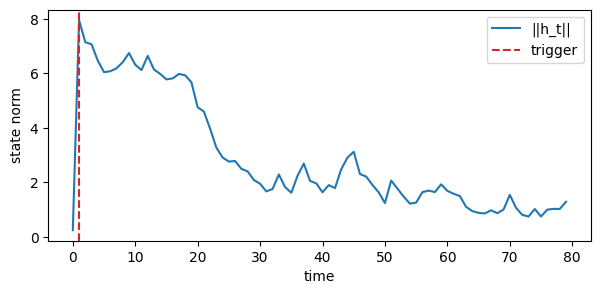

In [8]:
with torch.no_grad():
    # 1サンプルだけ取り出して、時刻ごとの状態h_tを観察する。
    x_one, y_one = make_trigger_memory_batch(batch_size=1, seq_len=80)
    logits, states, A = model(x_one, return_states=True)
    prob = logits.softmax(dim=-1)[0]

    # トリガーが出た時刻と、各時刻の状態ベクトルの大きさを取り出す。
    trigger_t = int(torch.nonzero(x_one[0, :, 0], as_tuple=False)[0].item())
    state_norm = states[0].norm(dim=-1).detach().cpu().numpy()

print('trigger_t:', trigger_t)
print('true label:', int(y_one.item()))
print('pred prob:', prob.detach().cpu().numpy().round(3))
print('state norm first 10:', state_norm[:10].round(3))
print('state norm around trigger:', state_norm[max(0, trigger_t-3):trigger_t+6].round(3))
print('state norm last 10:', state_norm[-10:].round(3))

if HAS_MPL:
    # トリガー時刻で状態が変化し、その後どう保持・減衰するかを見る。
    plt.figure(figsize=(7, 3))
    plt.plot(state_norm, label='||h_t||')
    plt.axvline(trigger_t, color='tab:red', linestyle='--', label='trigger')
    plt.xlabel('time')
    plt.ylabel('state norm')
    plt.legend()
    plt.show()

## 7. 実世界の気象データで1時間先の気温を予測する

ここでは、仙台の実際の気象観測データを使い、**直近24時間の気象から1時間後の気温を予測する**回帰タスクを行います。例えば、5月20日0時から23時までの気温・湿度・気圧・風・天気を順番にSSMへ入力し、5月21日0時の気温を予測します。

モデルが各時刻の入力を受け取るたびに、状態 `h_t` を `h_t = A h_{t-1} + B x_t` で更新します。最後に `C h_t` から1時間後の気温を出力します。つまり、ここでの状態は、直近24時間の気象変化を予測に使いやすい形へ圧縮した内部メモリです。

次の図は、1件の予測が作られるまでの処理を示します。

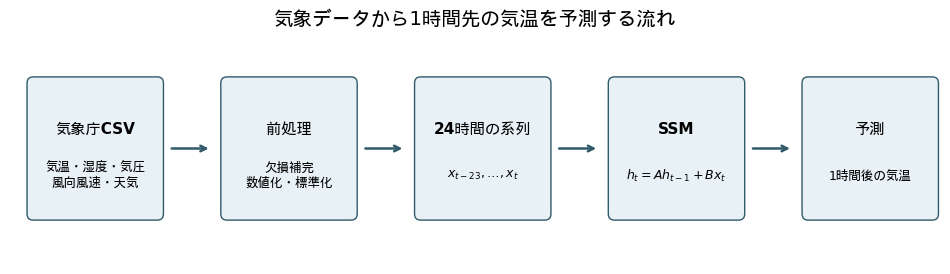

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import FancyBboxPatch

# このセルだけを単独実行しても日本語が表示されるよう、ここでもフォントを登録する。
japanese_font_path = '/usr/share/fonts/truetype/droid/DroidSansFallbackFull.ttf'
if Path(japanese_font_path).exists():
    font_manager.fontManager.addfont(japanese_font_path)
    japanese_font_name = font_manager.FontProperties(fname=japanese_font_path).get_name()
    # 日本語フォント単独では英数字が欠けるため、DejaVu Sansと併用する。
    plt.rcParams['font.family'] = ['DejaVu Sans', japanese_font_name]
plt.rcParams['axes.unicode_minus'] = False

# データから予測値までの処理フローを図示する。
fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis('off')

steps = [
    (0.3, '気象庁CSV', '気温・湿度・気圧\n風向風速・天気'),
    (2.8, '前処理', '欠損補完\n数値化・標準化'),
    (5.3, '24時間の系列', r'$x_{t-23},\ldots,x_t$'),
    (7.8, 'SSM', '$h_t=Ah_{t-1}+Bx_t$'),
    (10.3, '予測', '1時間後の気温'),
]

for x0, title, detail in steps:
    box = FancyBboxPatch(
        (x0, 0.65), 1.6, 1.7,
        boxstyle='round,pad=0.08', facecolor='#e8f1f5', edgecolor='#315b6b'
    )
    ax.add_patch(box)
    ax.text(x0 + 0.8, 1.75, title, ha='center', va='center', fontsize=11, weight='bold')
    ax.text(x0 + 0.8, 1.15, detail, ha='center', va='center', fontsize=9)

for x0 in [2.05, 4.55, 7.05, 9.55]:
    ax.annotate('', xy=(x0 + 0.55, 1.5), xytext=(x0, 1.5),
                arrowprops=dict(arrowstyle='->', lw=1.8, color='#315b6b'))

ax.set_title('気象データから1時間先の気温を予測する流れ', fontsize=14)
plt.show()

### 7.1 データの読み込みと前処理

今回のCSVは気象庁のダウンロード形式で、先頭6行が説明・ヘッダー、文字コードはCP932です。品質情報などの付属列は除き、実際の観測値だけを読み込みます。

風向は「北」と「北北東」が近い一方、「北」と「南」は遠いという周期的な値です。そのため、単純な番号ではなく角度の `sin` と `cos` に変換します。天気コードは大小関係のないカテゴリなので、one-hot表現に変換します。さらに、時刻と季節の周期も `sin/cos` で追加します。

In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

csv_path = Path('./data/data.csv')

# 気象庁CSVは先頭6行が説明・複数段ヘッダーなので、観測行だけを読む。
raw = pd.read_csv(csv_path, encoding='cp932', skiprows=6, header=None)

# 同じ観測項目に品質情報列が付いているため、実測値の列だけを選択する。
weather = pd.DataFrame({
    'datetime': pd.to_datetime(raw.iloc[:, 0], errors='coerce'),
    'temperature': pd.to_numeric(raw.iloc[:, 1], errors='coerce'),
    'humidity': pd.to_numeric(raw.iloc[:, 4], errors='coerce'),
    'pressure': pd.to_numeric(raw.iloc[:, 7], errors='coerce'),
    'wind_speed': pd.to_numeric(raw.iloc[:, 10], errors='coerce'),
    'wind_direction': raw.iloc[:, 12].astype('string'),
    'weather_code': raw.iloc[:, 15].astype('string'),
}).dropna(subset=['datetime']).sort_values('datetime')

# 時刻が抜けていても1時間間隔の表になるように並べ直す。
full_index = pd.date_range(weather['datetime'].min(), weather['datetime'].max(), freq='h')
weather = weather.set_index('datetime').reindex(full_index)
weather.index.name = 'datetime'

# 連続値は時間方向に補間し、カテゴリ値は直前・直後の値で補完する。
continuous = ['temperature', 'humidity', 'pressure', 'wind_speed']
weather[continuous] = weather[continuous].interpolate(limit_direction='both')
weather[['wind_direction', 'weather_code']] = (
    weather[['wind_direction', 'weather_code']].ffill().bfill()
)

# 16方位を角度に変換する。「静穏」は風向の影響を0にする。
directions = [
    '北', '北北東', '北東', '東北東', '東', '東南東', '南東', '南南東',
    '南', '南南西', '南西', '西南西', '西', '西北西', '北西', '北北西'
]
direction_to_angle = {name: 2 * np.pi * i / 16 for i, name in enumerate(directions)}
angle = weather['wind_direction'].map(direction_to_angle)
weather['wind_dir_sin'] = np.sin(angle).fillna(0.0)
weather['wind_dir_cos'] = np.cos(angle).fillna(0.0)

# 1日の周期と1年の周期を、端が連続するsin/cosで表現する。
hour_angle = 2 * np.pi * weather.index.hour / 24
day_angle = 2 * np.pi * weather.index.dayofyear / 365.25
weather['hour_sin'] = np.sin(hour_angle)
weather['hour_cos'] = np.cos(hour_angle)
weather['day_sin'] = np.sin(day_angle)
weather['day_cos'] = np.cos(day_angle)

# 天気コードには順序を仮定せず、コードごとの0/1列へ変換する。
weather_features = pd.get_dummies(
    weather,
    columns=['weather_code'],
    prefix='weather',
    dtype=float,
)

feature_columns = [
    'temperature', 'humidity', 'pressure', 'wind_speed',
    'wind_dir_sin', 'wind_dir_cos',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
] + [c for c in weather_features.columns if c.startswith('weather_')]

print('観測期間:', weather.index.min(), 'から', weather.index.max())
print('時間数:', len(weather))
print('入力特徴量数:', len(feature_columns))
display(weather.head())

観測期間: 2026-05-17 01:00:00 から 2026-06-18 00:00:00
時間数: 768
入力特徴量数: 15


,temperature,humidity,pressure,wind_speed,wind_direction,weather_code,wind_dir_sin,wind_dir_cos,hour_sin,hour_cos,day_sin,day_cos
datetime,,,,,,,,,,,,
2026-05-17 01:00:00,14.5,88,1013.1,3.3,北,2.0,0.000000,1.000000,0.258819,0.965926,0.706727,-0.707487
2026-05-17 02:00:00,13.7,92,1012.8,2.5,北北西,2.0,-0.382683,0.923880,0.500000,0.866025,0.706727,-0.707487
2026-05-17 03:00:00,13.6,93,1012.8,2.1,北北西,2.0,-0.382683,0.923880,0.707107,0.707107,0.706727,-0.707487
2026-05-17 04:00:00,13.9,91,1012.7,2.0,北西,2.0,-0.707107,0.707107,0.866025,0.500000,0.706727,-0.707487
2026-05-17 05:00:00,14.3,87,1012.8,1.8,北西,2.0,-0.707107,0.707107,0.965926,0.258819,0.706727,-0.707487


### 7.2 24時間の入力と正解を作る

時系列では、未来のデータを学習に混ぜると実運用より簡単な問題になってしまいます。そのため、古い70%を学習、続く15%を検証、最後の15%をテストに使います。標準化の平均と標準偏差も学習期間だけから計算します。

下図の青い24点がSSMへの入力、赤い点が予測対象です。

train / validation / test: 513 115 116


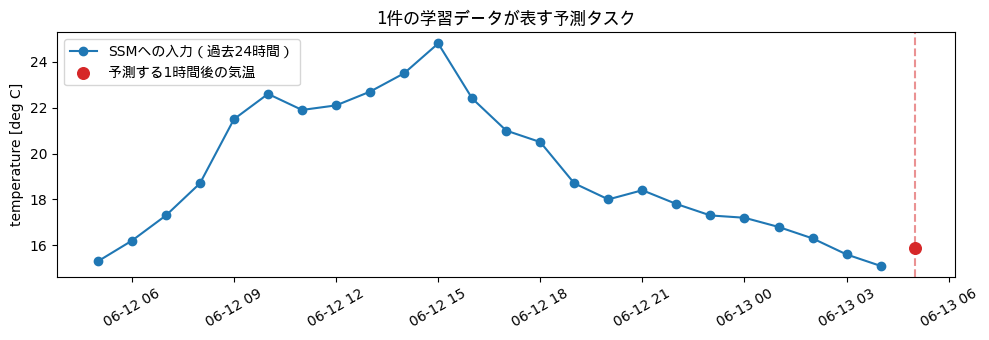

In [15]:
# 1サンプルに含める過去の時刻数。1時間間隔なので24は過去24時間を表す。
# これは状態数ではなく、入力テンソルXの時間軸の長さになる。
sequence_length = 24
n_rows = len(weather_features)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

# 未来の統計量が漏れないよう、標準化係数は学習期間だけで求める。
feature_mean = weather_features.iloc[:train_end][feature_columns].mean()
feature_std = weather_features.iloc[:train_end][feature_columns].std().replace(0, 1)
target_mean = weather_features.iloc[:train_end]['temperature'].mean()
target_std = weather_features.iloc[:train_end]['temperature'].std()

# features_scaledの形: (全時刻数, 入力特徴量数) = (768, 15)
features_scaled = (
    (weather_features[feature_columns] - feature_mean) / feature_std
).to_numpy(dtype=np.float32)
target_scaled = (
    (weather_features['temperature'] - target_mean) / target_std
).to_numpy(dtype=np.float32)

X, y, target_rows = [], [], []
for target_row in range(sequence_length, n_rows):
    # 1サンプルの形は(時間軸24, 特徴量軸15)。
    # target_row直前の24時間を入力し、target_rowの気温を正解にする。
    X.append(features_scaled[target_row-sequence_length:target_row])
    y.append(target_scaled[target_row])
    target_rows.append(target_row)

# Xの形: (サンプル数, 時間軸24, 特徴量軸15)
# yの形: (サンプル数, 予測値1個)
X = np.stack(X)
y = np.asarray(y, dtype=np.float32)[:, None]
target_rows = np.asarray(target_rows)

train_mask = target_rows < train_end
val_mask = (target_rows >= train_end) & (target_rows < val_end)
test_mask = target_rows >= val_end

# DataLoaderから得るxbの形は(バッチ数, 24, 15)、ybは(バッチ数, 1)。
def make_loader(mask, batch_size=64, shuffle=False):
    dataset = TensorDataset(torch.from_numpy(X[mask]), torch.from_numpy(y[mask]))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(train_mask, shuffle=True)
val_loader = make_loader(val_mask)
test_loader = make_loader(test_mask)

print('train / validation / test:', train_mask.sum(), val_mask.sum(), test_mask.sum())

# 1件の予測で、どの時間が入力になり、どの時刻を予測するかを示す。
example_target_row = target_rows[test_mask][0]
example_times = weather_features.index[
    example_target_row-sequence_length:example_target_row+1
]
example_temp = weather_features['temperature'].iloc[
    example_target_row-sequence_length:example_target_row+1
]

plt.figure(figsize=(10, 3.5))
plt.plot(example_times[:-1], example_temp.iloc[:-1], marker='o', label='SSMへの入力（過去24時間）')
plt.scatter(example_times[-1], example_temp.iloc[-1], color='tab:red', s=70,
            label='予測する1時間後の気温', zorder=3)
plt.axvline(example_times[-1], color='tab:red', linestyle='--', alpha=0.5)
plt.ylabel('temperature [deg C]')
plt.title('1件の学習データが表す予測タスク')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 7.3 SSMを学習する

`A`、`B`、`C` はあらかじめ決めるのではなく、実際の気温との誤差が小さくなるように学習します。今回は直前気温を直接出力へ渡す `D x_t` に相当する経路も使い、SSMは「直前気温から何度変化するか」を補正します。検証誤差が最も小さい時点のモデルを保存し、最後に未使用のテスト期間で評価します。

比較対象として「1時間後も現在と同じ気温」と予測する持続予測も計算します。SSMのMAEがこれより小さければ、複数の気象要素や24時間の変化を利用できたと解釈できます。

#### 学習処理の詳細


#### 学習時に畳み込みを使わない理由

今回のコードは、学習時も `for t in range(sequence_length)` による再帰計算を使います。24時間の入力を古い順に読み、各時刻で `h_t = A h_{t-1} + B x_t` を直接計算しています。PyTorchはこの24回の計算履歴を保持し、最後の損失から時間方向へ誤差逆伝播します。

一方、今回のように `A`、`B`、`C` が全時刻で固定された線形SSMは、再帰式を展開すると `K = [CB, CAB, CA^2B, ...]` というカーネルと入力系列の畳み込みとしても計算できます。S4などでは、この性質を利用して長い系列の学習を並列化・高速化します。再帰計算と畳み込み計算は、同じパラメータであれば数学的に同じ出力を表せます。

この教材で再帰計算を採用したのは、系列長が24と短く速度上の問題が小さいこと、状態更新式とコードの対応が明確なこと、各時刻の内部状態 `h_t` をそのまま可視化できることが理由です。畳み込み版に書き換えることは可能ですが、現在の気象予測コードでは実装していません。

Mambaでは、`B_t`、`C_t`、`Delta_t` が入力に応じて時刻ごとに変わります。そのため、系列全体で固定された通常の畳み込みカーネルには変換できません。Mambaは再帰的な依存関係を保ちながら並列処理するselective scanを使用します。今回の単純な再帰SSM、固定SSMの畳み込み、Mambaのselective scanは区別して考える必要があります。
#### 学習の流れ

このモデルの学習は、次の手順を1バッチずつ繰り返して進みます。

1. **学習データを取り出す**: `train_loader` から、過去24時間の気象系列 `x` と、その1時間後の実測気温 `y` を取り出します。複数の系列を1バッチにまとめてGPUで並列処理します。
2. **初期状態を作る**: 各系列の先頭で内部状態 `h_0` をゼロにします。したがって、前のバッチや別の日の状態が持ち越されることはありません。
3. **24時間を順番に読む**: 古い時刻から順に、`h_t = A h_{t-1} + B x_t` を24回計算します。`A h_{t-1}` は過去の情報の保持、`B x_t` は現在の気象情報の書き込みに対応します。`A` は `sigmoid` によって0から1の範囲に制約しています。
4. **1時間後の気温を予測する**: 最後の状態 `h_24` を `C` で読み出します。この教材では `y_hat = x_last,temp + C h_24` とし、直前の気温にSSMが予測した変化量を加えます。最初の項はSSMの出力式における直接項 `D x_t` に相当します。
5. **予測誤差を計算する**: 予測値 `y_hat` と実測値 `y` の平均二乗誤差 `MSE = mean((y_hat - y)^2)` を計算します。予測が外れるほど損失が大きくなります。
6. **誤差を時間方向へ戻す**: `loss.backward()` により、最後の予測から24回の状態更新を逆向きにたどって勾配を計算します。これをBackpropagation Through Time（BPTT、通時的誤差逆伝播）と呼びます。
7. **パラメータを更新する**: `optimizer.step()` が勾配を使って `A`、`B`、`C` を少しずつ更新します。このノートブックではAdamWを使用します。これをすべての学習バッチに対して行ったものが1エポックです。
8. **検証データでモデルを選ぶ**: 各エポック後に、学習には使わない検証期間のMSEを計算します。検証MSEが最も小さかった時点のパラメータを保存し、そのモデルだけを最後のテスト期間で評価します。

学習時には上記の誤差逆伝播と更新を行いますが、検証・テスト・実運用時には勾配を計算せず、手順2から4の順伝播だけを行います。

#### 参照できる過去の長さ

このノートブックでは `sequence_length = 24` としており、サンプルごとに初期状態 `h_0` をゼロへ戻します。したがって、モデルが実際に参照できる過去は最大24時間です。それ以前の観測値は入力されないため、`A` が1に近くても24時間より前の情報を見ることはできません。

`A` は24時間の範囲内で情報が残る長さを制御します。ある状態成分の係数が `A=0.9` なら、`k` 時間前の影響はおよそ `0.9^k` 倍になります。より長い履歴を使うには `sequence_length` を72や168へ増やします。ただし、データ量、計算量、誤差逆伝播する長さも増えるため、今回の約1か月のデータでは24時間を採用しています。

device: cuda
epoch   1 | train MSE 0.0351 | val MSE 0.0355
epoch  20 | train MSE 0.0340 | val MSE 0.0357
epoch  40 | train MSE 0.0308 | val MSE 0.0365
epoch  60 | train MSE 0.0311 | val MSE 0.0325
epoch  80 | train MSE 0.0338 | val MSE 0.0465
epoch 100 | train MSE 0.0291 | val MSE 0.0374
epoch 120 | train MSE 0.0284 | val MSE 0.0450


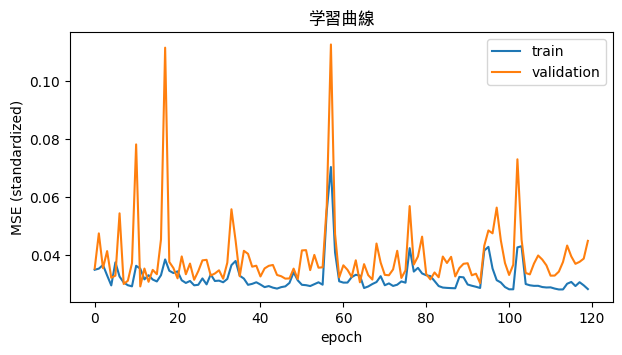

In [16]:
import copy
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

class WeatherSSM(nn.Module):
    def __init__(self, input_dim, state_dim=64):
        # input_dim: 各時刻の特徴量数。今回のデータでは15。
        # state_dim: 内部状態h_tの成分数。ユーザーが決めるハイパーパラメータ。
        super().__init__()
        # Aの形: (state_dim,) = (64,)。状態64成分を個別に保持・減衰させる。
        self.logit_A = nn.Parameter(torch.full((state_dim,), 2.0))
        # B: 各時刻の入力を15次元から64次元へ変換する。
        # B.weightの形: (state_dim, input_dim) = (64, 15)
        self.B = nn.Linear(input_dim, state_dim)
        # C: 最後の状態を64次元から気温補正値1個へ変換する。
        # C.weightの形: (1, state_dim) = (1, 64)
        self.C = nn.Linear(state_dim, 1)
        # 最初は補正量を0とし、学習開始時点では持続予測と同じ出力にする。
        nn.init.zeros_(self.C.weight)
        nn.init.zeros_(self.C.bias)

    def forward(self, x, return_states=False):
        # xの形: (バッチ数, 時間軸24, 特徴量軸15)
        batch_size, sequence_length, _ = x.shape
        # hの形: (バッチ数, 状態数64)
        h = torch.zeros(batch_size, self.logit_A.numel(), device=x.device)
        states = []

        # sigmoidにより0 < A < 1とし、状態が発散しないようにする。
        A = torch.sigmoid(self.logit_A)
        # 時間軸を24回ループする。x[:, t]は(バッチ数, 15)、Bの出力は(バッチ数, 64)。
        for t in range(sequence_length):
            h = A * h + self.B(x[:, t])
            if return_states:
                states.append(h)

        # 最後の観測気温に、SSMが求めた変化量を加える。
        # これは出力式 y_t = C h_t + D x_t の直接項Dに対応する。
        last_temperature = x[:, -1, :1]
        # C(h)とpredictionの形: (バッチ数, 1)
        prediction = last_temperature + self.C(h)
        if return_states:
            return prediction, torch.stack(states, dim=1), A
        return prediction

# 状態数は学習で決まる値ではなく、ユーザーが事前に選ぶハイパーパラメータ。
# 64は表現力と計算量のバランスを取った、この教材での設定値。
state_dim = 64
model = WeatherSSM(input_dim=len(feature_columns), state_dim=state_dim).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

def evaluate_loss(loader):
    model.eval()
    total_loss, total_count = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb), yb)
            total_loss += loss.item() * len(xb)
            total_count += len(xb)
    return total_loss / total_count

epochs = 120
train_history, val_history = [], []
best_val_loss = float('inf')
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss, epoch_count = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        prediction = model(xb)
        loss = loss_fn(prediction, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(xb)
        epoch_count += len(xb)

    train_loss = epoch_loss / epoch_count
    val_loss = evaluate_loss(val_loader)
    train_history.append(train_loss)
    val_history.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % 20 == 0:
        print(f'epoch {epoch:3d} | train MSE {train_loss:.4f} | val MSE {val_loss:.4f}')

# 検証期間で最も良かったパラメータをテストに使う。
model.load_state_dict(best_state)

plt.figure(figsize=(7, 3.5))
plt.plot(train_history, label='train')
plt.plot(val_history, label='validation')
plt.xlabel('epoch')
plt.ylabel('MSE (standardized)')
plt.title('学習曲線')
plt.legend()
plt.show()

### 7.4 予測結果と内部状態を図示する

上段では、テスト期間の実測気温と予測気温を比較します。下段では、各状態成分 `h_t` の値を色で表示します。横軸が24時間、縦軸が状態成分です。色が時間とともに変わる様子から、SSMが気象入力を内部状態へ蓄積していることを確認できます。

SSM test MAE: 0.602 deg C
Persistence baseline MAE: 0.784 deg C


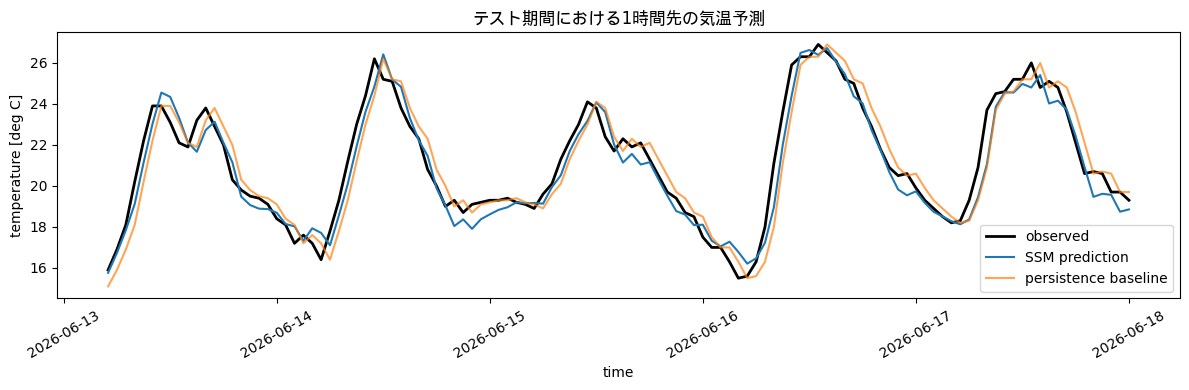

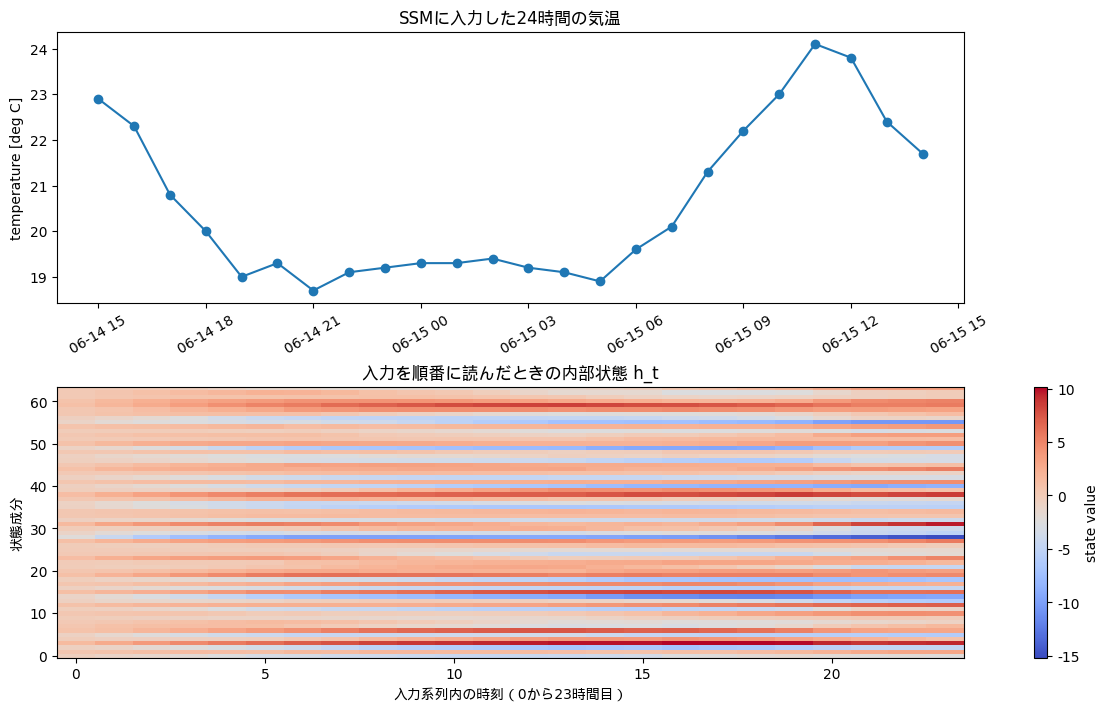

予測対象時刻: 2026-06-15 15:00:00
予測気温: 21.14 deg C / 実測気温: 22.30 deg C
学習したAの範囲: 0.8753451704978943 から 0.8839600682258606
Aから計算した半減時間: 中央値 5.4 時間, 最大 5.6 時間
モデルが実際に参照する過去: 最大 24 時間


In [19]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import font_manager

# この結果セルだけを再実行しても日本語が表示されるよう、フォントを登録する。
japanese_font_path = '/usr/share/fonts/truetype/droid/DroidSansFallbackFull.ttf'
if Path(japanese_font_path).exists():
    font_manager.fontManager.addfont(japanese_font_path)
    japanese_font_name = font_manager.FontProperties(fname=japanese_font_path).get_name()
    plt.rcParams['font.family'] = ['DejaVu Sans', japanese_font_name]
plt.rcParams['axes.unicode_minus'] = False

def predict_loader(loader):
    predictions, targets = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb.to(device)).cpu().numpy()
            predictions.append(pred)
            targets.append(yb.numpy())
    return np.concatenate(predictions).ravel(), np.concatenate(targets).ravel()

pred_scaled, true_scaled = predict_loader(test_loader)

# 標準化された値を摂氏へ戻す。
pred_temperature = pred_scaled * target_std + target_mean
true_temperature = true_scaled * target_std + target_mean
test_times = weather_features.index[target_rows[test_mask]]

model_mae = np.mean(np.abs(pred_temperature - true_temperature))

# 持続予測: 直前時刻の気温を、そのまま1時間後の予測値とする。
persistence_temperature = weather_features['temperature'].iloc[
    target_rows[test_mask] - 1
].to_numpy()
persistence_mae = np.mean(np.abs(persistence_temperature - true_temperature))

print(f'SSM test MAE: {model_mae:.3f} deg C')
print(f'Persistence baseline MAE: {persistence_mae:.3f} deg C')

plt.figure(figsize=(12, 4))
plt.plot(test_times, true_temperature, label='observed', color='black', linewidth=2)
plt.plot(test_times, pred_temperature, label='SSM prediction', color='tab:blue')
plt.plot(test_times, persistence_temperature, label='persistence baseline',
         color='tab:orange', alpha=0.7)
plt.xlabel('time')
plt.ylabel('temperature [deg C]')
plt.title('テスト期間における1時間先の気温予測')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# テスト期間の1サンプルをモデルへ通し、全時刻の内部状態を取得する。
sample_index = len(X[test_mask]) // 2
sample_x = torch.from_numpy(X[test_mask][sample_index:sample_index+1]).to(device)
with torch.no_grad():
    sample_prediction, sample_states, learned_A = model(sample_x, return_states=True)

state_image = sample_states[0].cpu().numpy().T
sample_target_row = target_rows[test_mask][sample_index]
sample_time = weather_features.index[
    sample_target_row-sequence_length:sample_target_row
]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), constrained_layout=True)

axes[0].plot(sample_time, weather_features['temperature'].iloc[
    sample_target_row-sequence_length:sample_target_row
], marker='o')
axes[0].set_ylabel('temperature [deg C]')
axes[0].set_title('SSMに入力した24時間の気温')
axes[0].tick_params(axis='x', rotation=30)

image = axes[1].imshow(state_image, aspect='auto', cmap='coolwarm', origin='lower')
axes[1].set_xlabel('入力系列内の時刻（0から23時間目）')
axes[1].set_ylabel('状態成分')
axes[1].set_title('入力を順番に読んだときの内部状態 h_t')
fig.colorbar(image, ax=axes[1], label='state value')
plt.show()

pred_c = sample_prediction.item() * target_std + target_mean
true_c = weather_features['temperature'].iloc[sample_target_row]
print('予測対象時刻:', weather_features.index[sample_target_row])
print(f'予測気温: {pred_c:.2f} deg C / 実測気温: {true_c:.2f} deg C')
print('学習したAの範囲:', float(learned_A.min()), 'から', float(learned_A.max()))

# A^k = 0.5となるkを、各状態成分の「半減時間」の目安として計算する。
# ただし、このモデルへ実際に渡している入力は直近24時間だけである。
A_values = learned_A.detach().cpu().numpy()
half_life_hours = np.log(0.5) / np.log(A_values)
print(f'Aから計算した半減時間: 中央値 {np.median(half_life_hours):.1f} 時間, '
      f'最大 {np.max(half_life_hours):.1f} 時間')
print(f'モデルが実際に参照する過去: 最大 {sequence_length} 時間')